In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder.appName(
    "Colab PySpark").getOrCreate()

# Create DataFrame
data = [("James", 34), ("Anna", 28), ("Tom", 23)]
df = spark.createDataFrame(data, ["Name", "Age"])

print("Original Data:")
df.show()

print("Filtered (Age > 25):")
df.filter(col("Age") > 25).show()

print("GroupBy Age:")
df.groupBy("Age").count().show()

# SQL
df.createOrReplaceTempView("people")
spark.sql("SELECT * FROM people WHERE Age > 25").show()

# RDD
rdd = spark.sparkContext.parallelize([1,2,3,4,5])
print("RDD squared:", rdd.map(lambda x: x**2).collect())

Original Data:
+-----+---+
| Name|Age|
+-----+---+
|James| 34|
| Anna| 28|
|  Tom| 23|
+-----+---+

Filtered (Age > 25):
+-----+---+
| Name|Age|
+-----+---+
|James| 34|
| Anna| 28|
+-----+---+

GroupBy Age:
+---+-----+
|Age|count|
+---+-----+
| 34|    1|
| 28|    1|
| 23|    1|
+---+-----+

+-----+---+
| Name|Age|
+-----+---+
|James| 34|
| Anna| 28|
+-----+---+

RDD squared: [1, 4, 9, 16, 25]


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Walmart_Weekly_Sales_Forecasting")
    .getOrCreate()
)

spark

In [29]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_date

train_df = spark.read.csv("/content/train.csv", header=True, inferSchema=True)
features_df = spark.read.csv("/content/features.csv", header=True, inferSchema=True, nullValue="NA")
stores_df = spark.read.csv("/content/stores.csv", header=True, inferSchema=True)

train_df = train_df.withColumn("Date", to_date("Date", "yyyy-MM-dd"))
features_df = features_df.withColumn("Date", to_date("Date", "yyyy-MM-dd"))

numeric_feature_cols = [
    "Temperature", "Fuel_Price", "MarkDown1", "MarkDown2", "MarkDown3",
    "MarkDown4", "MarkDown5", "CPI", "Unemployment"
]

for c in numeric_feature_cols:
    features_df = features_df.withColumn(c, col(c).cast("double"))

df = (
    train_df
    .join(features_df, on=["Store", "Date", "IsHoliday"], how="left")
    .join(stores_df, on="Store", how="left")
)

In [30]:
train_df.printSchema()
features_df.printSchema()
stores_df.printSchema()

train_df.show(5)
features_df.show(5)
stores_df.show(5)

root
 |-- Store: integer (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: double (nullable = true)
 |-- MarkDown2: double (nullable = true)
 |-- MarkDown3: double (nullable = true)
 |-- MarkDown4: double (nullable = true)
 |-- MarkDown5: double (nullable = true)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)
 |-- IsHoliday: boolean (nullable = true)

root
 |-- Store: integer (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)

+-----+----+----------+------------+---------+
|Store|Dept|      Date|Weekly_Sales|IsHoliday|
+-----+----+----------+------------+---------+
|    1|   1|2010-02-05|     24924.5|    false|
|    

In [31]:
from pyspark.sql.functions import col

df = (
    train_df
    .join(features_df, on=["Store", "Date", "IsHoliday"], how="left")
    .join(stores_df, on=["Store"], how="left")
)

print("Joined rows:", df.count())
df.printSchema()
df.show(5)

Joined rows: 421570
root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: double (nullable = true)
 |-- MarkDown2: double (nullable = true)
 |-- MarkDown3: double (nullable = true)
 |-- MarkDown4: double (nullable = true)
 |-- MarkDown5: double (nullable = true)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)

+-----+----------+---------+----+------------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+----+------+
|Store|      Date|IsHoliday|Dept|Weekly_Sales|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|        CPI|Unemployment|Type|  Size|
+-----+----------+-----

In [32]:
from pyspark.sql.functions import to_date, year, month, weekofyear, dayofmonth, quarter

df = df.withColumn("Date", to_date(col("Date"), "yyyy-MM-dd"))

df = (
    df.withColumn("Year", year("Date"))
      .withColumn("Month", month("Date"))
      .withColumn("WeekOfYear", weekofyear("Date"))
      .withColumn("DayOfMonth", dayofmonth("Date"))
      .withColumn("Quarter", quarter("Date"))
)

df.printSchema()
df.show(5)

root
 |-- Store: integer (nullable = true)
 |-- Date: date (nullable = true)
 |-- IsHoliday: boolean (nullable = true)
 |-- Dept: integer (nullable = true)
 |-- Weekly_Sales: double (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Fuel_Price: double (nullable = true)
 |-- MarkDown1: double (nullable = true)
 |-- MarkDown2: double (nullable = true)
 |-- MarkDown3: double (nullable = true)
 |-- MarkDown4: double (nullable = true)
 |-- MarkDown5: double (nullable = true)
 |-- CPI: double (nullable = true)
 |-- Unemployment: double (nullable = true)
 |-- Type: string (nullable = true)
 |-- Size: integer (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Month: integer (nullable = true)
 |-- WeekOfYear: integer (nullable = true)
 |-- DayOfMonth: integer (nullable = true)
 |-- Quarter: integer (nullable = true)

+-----+----------+---------+----+------------+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+----+------+

In [33]:
from pyspark.sql.functions import when, count

missing_counts = df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in df.columns
])

missing_counts.show(truncate=False)

+-----+----+---------+----+------------+-----------+----------+---------+---------+---------+---------+---------+---+------------+----+----+----+-----+----------+----------+-------+
|Store|Date|IsHoliday|Dept|Weekly_Sales|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|CPI|Unemployment|Type|Size|Year|Month|WeekOfYear|DayOfMonth|Quarter|
+-----+----+---------+----+------------+-----------+----------+---------+---------+---------+---------+---------+---+------------+----+----+----+-----+----------+----------+-------+
|0    |0   |0        |0   |0           |0          |0         |270889   |310322   |284479   |286603   |270138   |0  |0           |0   |0   |0   |0    |0         |0         |0      |
+-----+----+---------+----+------------+-----------+----------+---------+---------+---------+---------+---------+---+------------+----+----+----+-----+----------+----------+-------+



In [52]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
fill_median_cols = ["CPI", "Unemployment", "Fuel_Price", "Temperature"]

df = df.fillna(0, subset=markdown_cols)

for c in fill_median_cols:
    median_value = df.approxQuantile(c, [0.5], 0.01)[0]
    df = df.fillna({c: float(median_value)})

In [53]:
q1, q3 = df.approxQuantile("Weekly_Sales", [0.25, 0.75], 0.01)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

df_clean = df.filter((col("Weekly_Sales") >= lower_bound) & (col("Weekly_Sales") <= upper_bound))

print("Rows before outlier removal:", df.count())
print("Rows after outlier removal:", df_clean.count())

Q1: 2108.4
Q3: 20098.19
Lower bound: -24876.284999999996
Upper bound: 47082.875
Rows before outlier removal: 421570
Rows after outlier removal: 385631


In [54]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (10, 5)

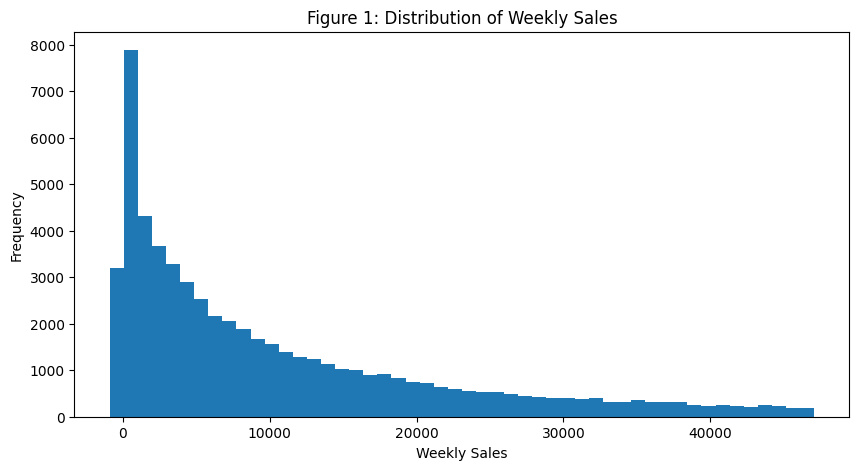

In [55]:
sales_pd = df_clean.select("Weekly_Sales").sample(False, 0.15, seed=42).toPandas()

plt.figure()
plt.hist(sales_pd["Weekly_Sales"], bins=50)
plt.title("Figure 1: Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")
plt.show()

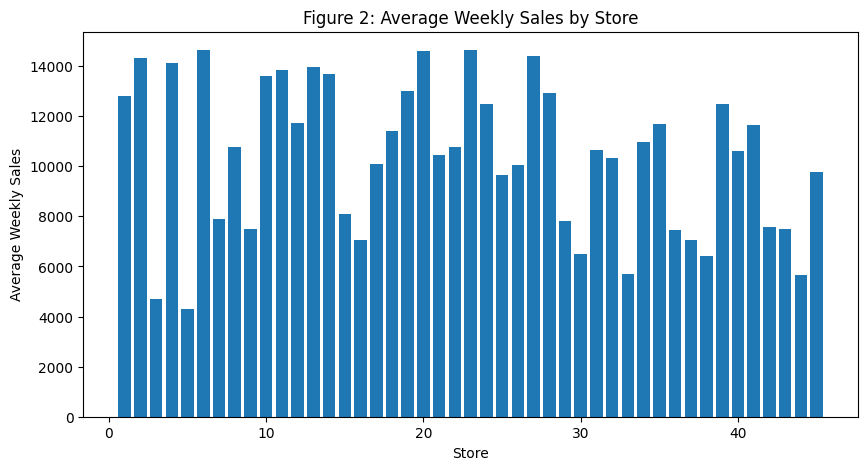

In [56]:
store_sales = (
    df_clean.groupBy("Store")
    .avg("Weekly_Sales")
    .orderBy("Store")
    .toPandas()
)

plt.figure()
plt.bar(store_sales["Store"], store_sales["avg(Weekly_Sales)"])
plt.title("Figure 2: Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.show()

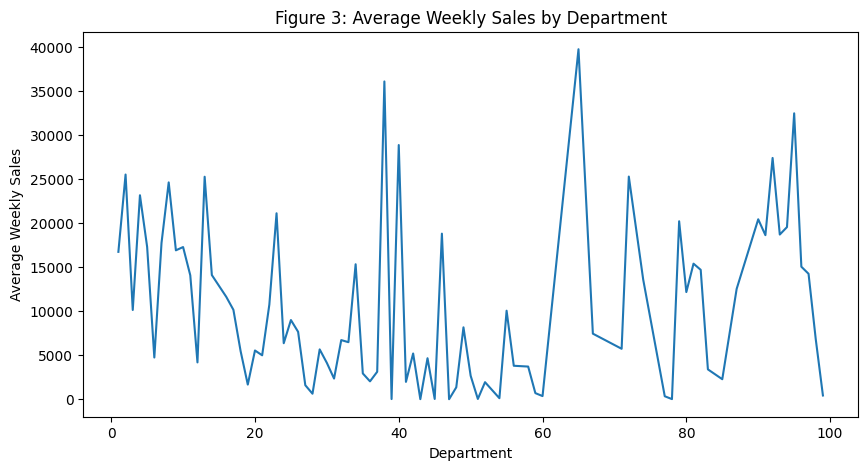

In [57]:
dept_sales = (
    df_clean.groupBy("Dept")
    .avg("Weekly_Sales")
    .orderBy("Dept")
    .toPandas()
)

plt.figure()
plt.plot(dept_sales["Dept"], dept_sales["avg(Weekly_Sales)"])
plt.title("Figure 3: Average Weekly Sales by Department")
plt.xlabel("Department")
plt.ylabel("Average Weekly Sales")
plt.show()

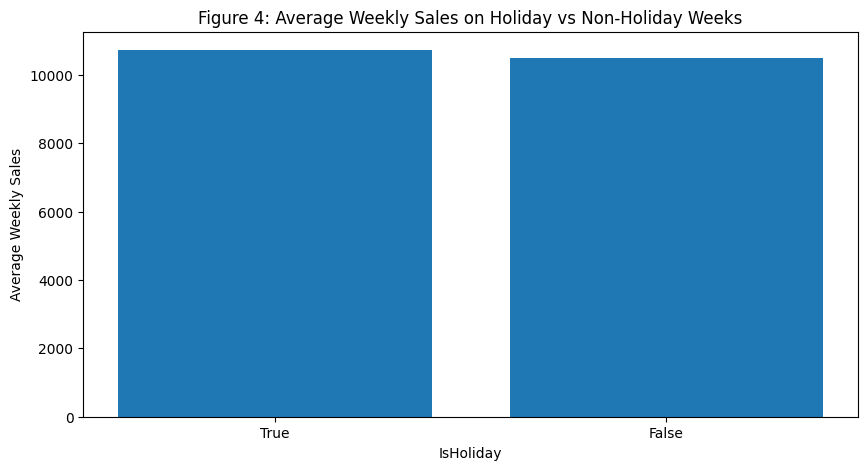

In [58]:
holiday_sales = (
    df_clean.groupBy("IsHoliday")
    .avg("Weekly_Sales")
    .toPandas()
)

plt.figure()
plt.bar(holiday_sales["IsHoliday"].astype(str), holiday_sales["avg(Weekly_Sales)"])
plt.title("Figure 4: Average Weekly Sales on Holiday vs Non-Holiday Weeks")
plt.xlabel("IsHoliday")
plt.ylabel("Average Weekly Sales")
plt.show()

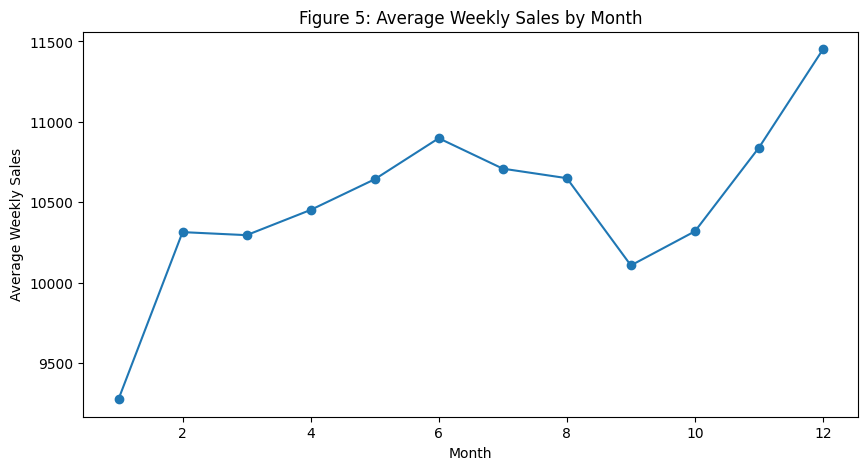

In [59]:
monthly_sales = (
    df_clean.groupBy("Month")
    .avg("Weekly_Sales")
    .orderBy("Month")
    .toPandas()
)

plt.figure()
plt.plot(monthly_sales["Month"], monthly_sales["avg(Weekly_Sales)"], marker="o")
plt.title("Figure 5: Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

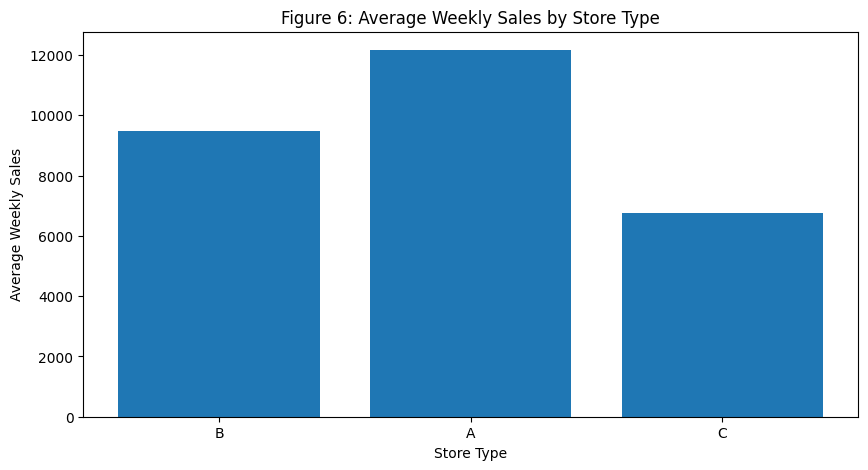

In [60]:
type_sales = (
    df_clean.groupBy("Type")
    .avg("Weekly_Sales")
    .toPandas()
)

plt.figure()
plt.bar(type_sales["Type"], type_sales["avg(Weekly_Sales)"])
plt.title("Figure 6: Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")
plt.show()

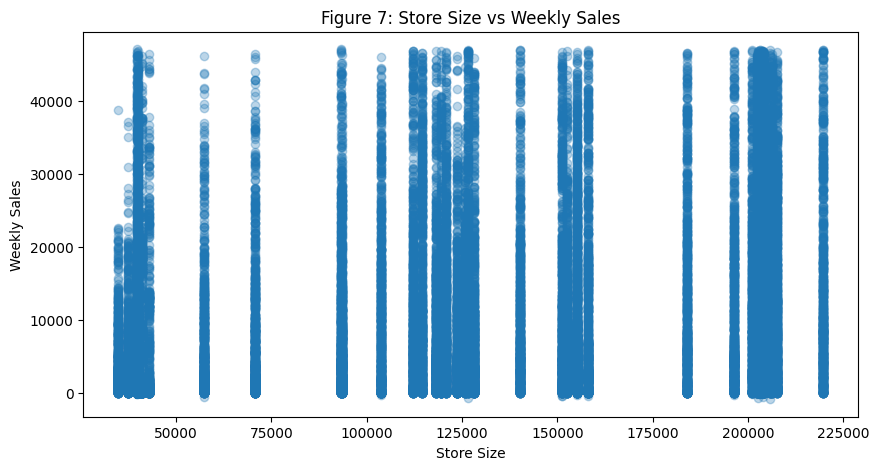

In [61]:
size_sales = df_clean.select("Size", "Weekly_Sales").sample(False, 0.10, seed=42).toPandas()

plt.figure()
plt.scatter(size_sales["Size"], size_sales["Weekly_Sales"], alpha=0.3)
plt.title("Figure 7: Store Size vs Weekly Sales")
plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")
plt.show()

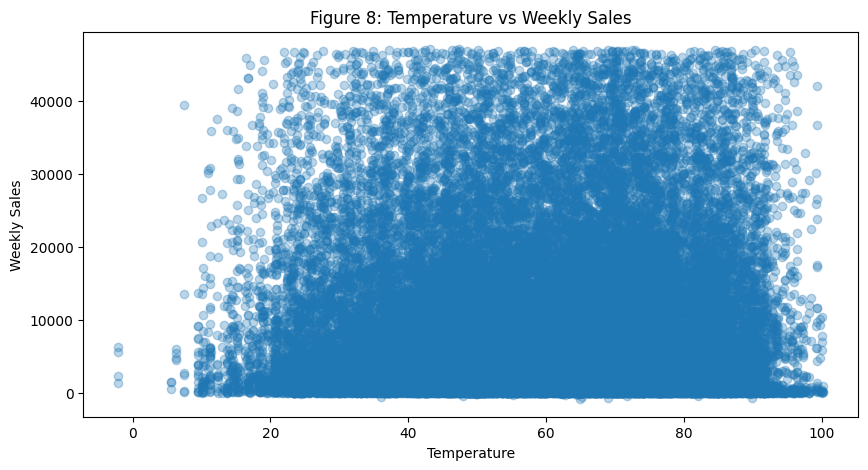

In [62]:
temp_sales = df_clean.select("Temperature", "Weekly_Sales").sample(False, 0.10, seed=42).toPandas()

plt.figure()
plt.scatter(temp_sales["Temperature"], temp_sales["Weekly_Sales"], alpha=0.3)
plt.title("Figure 8: Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

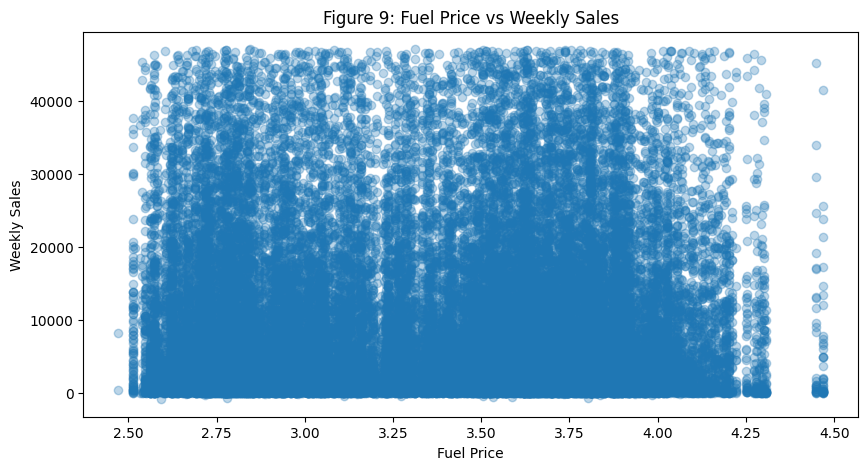

In [63]:
fuel_sales = df_clean.select("Fuel_Price", "Weekly_Sales").sample(False, 0.10, seed=42).toPandas()

plt.figure()
plt.scatter(fuel_sales["Fuel_Price"], fuel_sales["Weekly_Sales"], alpha=0.3)
plt.title("Figure 9: Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")
plt.show()

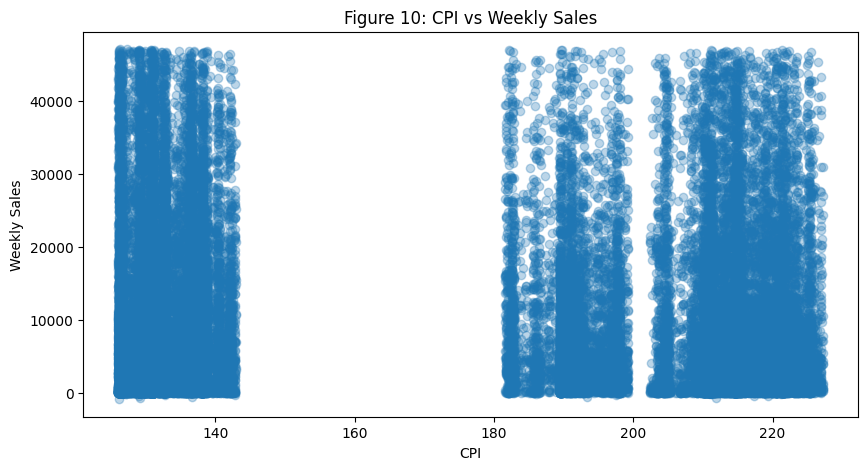

In [64]:
cpi_sales = df_clean.select("CPI", "Weekly_Sales").sample(False, 0.10, seed=42).toPandas()

plt.figure()
plt.scatter(cpi_sales["CPI"], cpi_sales["Weekly_Sales"], alpha=0.3)
plt.title("Figure 10: CPI vs Weekly Sales")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")
plt.show()

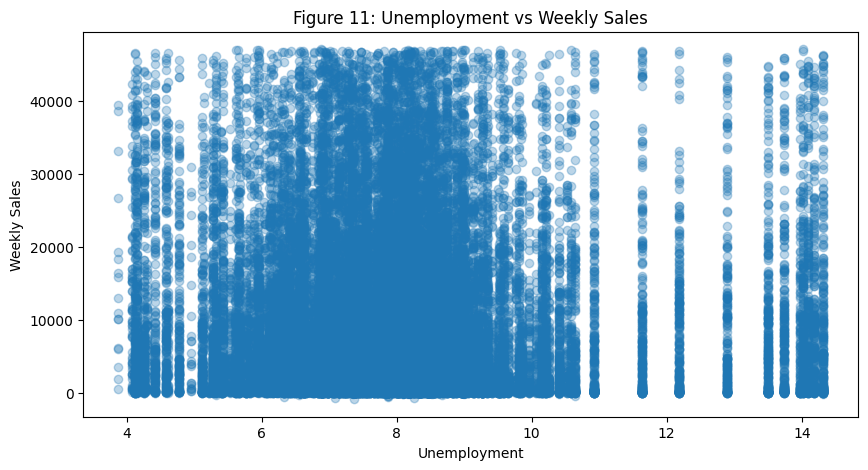

In [65]:
unemp_sales = df_clean.select("Unemployment", "Weekly_Sales").sample(False, 0.10, seed=42).toPandas()

plt.figure()
plt.scatter(unemp_sales["Unemployment"], unemp_sales["Weekly_Sales"], alpha=0.3)
plt.title("Figure 11: Unemployment vs Weekly Sales")
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")
plt.show()

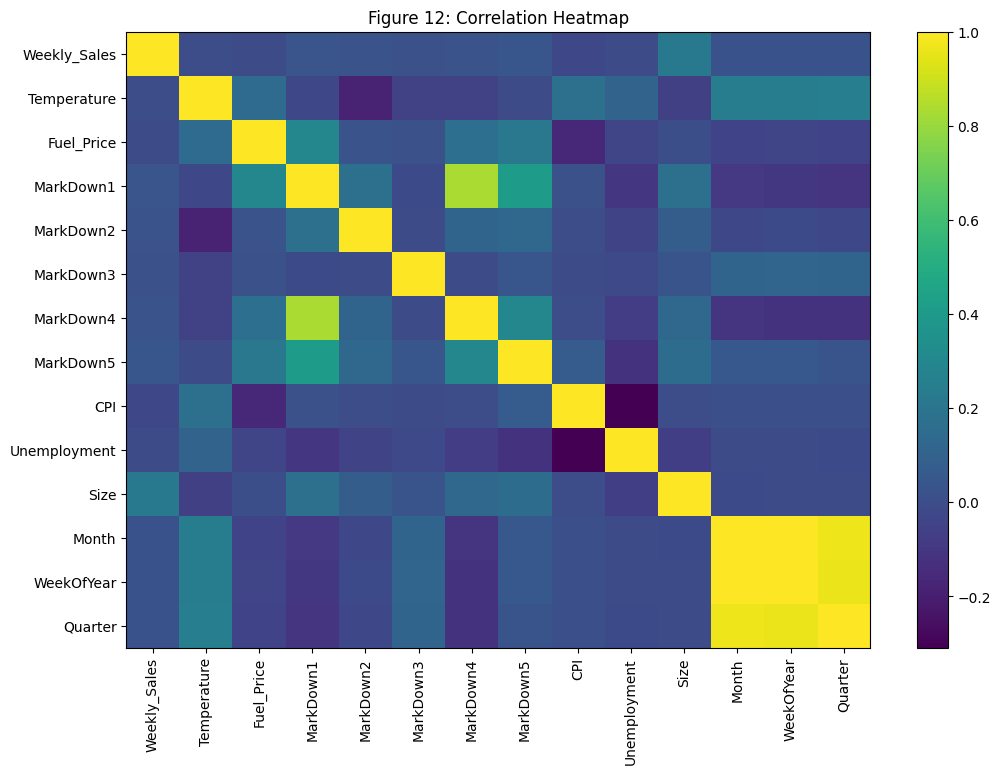

In [66]:
numeric_cols_for_corr = [
    "Weekly_Sales", "Temperature", "Fuel_Price", "MarkDown1", "MarkDown2",
    "MarkDown3", "MarkDown4", "MarkDown5", "CPI", "Unemployment", "Size",
    "Month", "WeekOfYear", "Quarter"
]

corr_pd = df_clean.select(numeric_cols_for_corr).sample(False, 0.10, seed=42).toPandas()
corr_matrix = corr_pd.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Figure 12: Correlation Heatmap")
plt.show()

In [67]:
from pyspark.sql.functions import when

df_model = df_clean.withColumn("IsHolidayNum", when(col("IsHoliday") == True, 1).otherwise(0))

feature_cols = [
    "Store", "Dept", "Temperature", "Fuel_Price",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment", "Size",
    "Year", "Month", "WeekOfYear", "DayOfMonth", "Quarter",
    "IsHolidayNum", "Type"
]

target_col = "Weekly_Sales"

df_model.select(feature_cols + [target_col]).show(5)

+-----+----+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+------+----+-----+----------+----------+-------+------------+----+------------+
|Store|Dept|Temperature|Fuel_Price|MarkDown1|MarkDown2|MarkDown3|MarkDown4|MarkDown5|        CPI|Unemployment|  Size|Year|Month|WeekOfYear|DayOfMonth|Quarter|IsHolidayNum|Type|Weekly_Sales|
+-----+----+-----------+----------+---------+---------+---------+---------+---------+-----------+------------+------+----+-----+----------+----------+-------+------------+----+------------+
|    1|   1|      42.31|     2.572|      0.0|      0.0|      0.0|      0.0|      0.0|211.0963582|       8.106|151315|2010|    2|         5|         5|      1|           0|   A|     24924.5|
|    1|   1|      38.51|     2.548|      0.0|      0.0|      0.0|      0.0|      0.0|211.2421698|       8.106|151315|2010|    2|         6|        12|      1|           1|   A|    46039.49|
|    1|   1|      39.93|     2.514|      0.0|     

In [68]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

indexer = StringIndexer(inputCol="Type", outputCol="TypeIndex", handleInvalid="keep")
encoder = OneHotEncoder(inputCols=["TypeIndex"], outputCols=["TypeVec"])

numeric_features = [
    "Store", "Dept", "Temperature", "Fuel_Price",
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment", "Size",
    "Year", "Month", "WeekOfYear", "DayOfMonth", "Quarter",
    "IsHolidayNum"
]

assembler = VectorAssembler(
    inputCols=numeric_features + ["TypeVec"],
    outputCol="features"
)

In [69]:
train_data, valid_data = df_model.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_data.count())
print("Validation rows:", valid_data.count())

Training rows: 308416
Validation rows: 77215


In [70]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target_col,
    predictionCol="prediction",
    numTrees=100,
    maxDepth=10,
    seed=42
)

pipeline = Pipeline(stages=[indexer, encoder, assembler, rf])

rf_model = pipeline.fit(train_data)
predictions = rf_model.transform(valid_data)

predictions.select(target_col, "prediction").show(10)

+------------+------------------+
|Weekly_Sales|        prediction|
+------------+------------------+
|    39954.04|22274.541690235375|
|    40129.01|24388.308906081176|
|     30721.5| 24114.70920520926|
|    10217.55| 9419.928680991896|
|    13623.98| 7381.584543759996|
|    11737.12| 7727.442656811214|
|    11875.84| 6189.979416038488|
|     1011.83| 6770.937717272141|
|       439.0| 5613.645603516946|
|    21249.31| 5613.645603516946|
+------------+------------------+
only showing top 10 rows


In [71]:
from pyspark.ml.evaluation import RegressionEvaluator

rmse_eval = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
mae_eval = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")
r2_eval = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")

rmse = rmse_eval.evaluate(predictions)
mae = mae_eval.evaluate(predictions)
r2 = r2_eval.evaluate(predictions)

print("Model Results")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2)

Model Results
RMSE: 8419.080762724516
MAE : 6112.945734669425
R2  : 0.4417363748369846


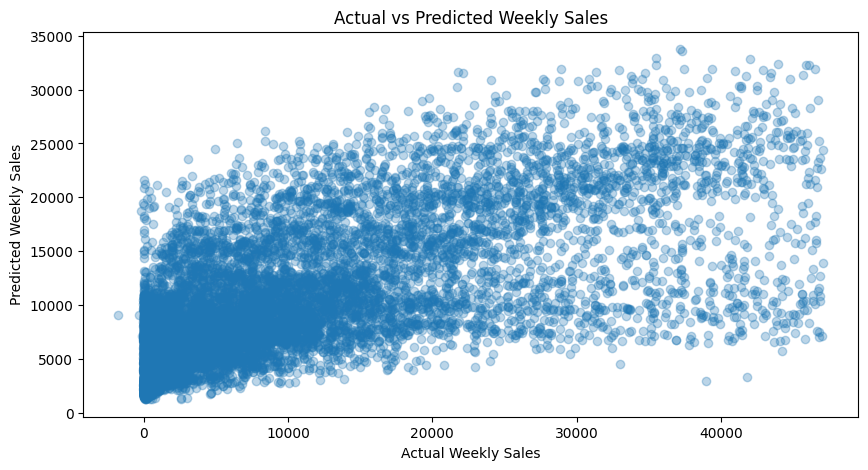

In [72]:
pred_pd = predictions.select(target_col, "prediction").sample(False, 0.15, seed=42).toPandas()

plt.figure()
plt.scatter(pred_pd[target_col], pred_pd["prediction"], alpha=0.3)
plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.show()

In [73]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol="features",
    labelCol=target_col,
    predictionCol="prediction",
    maxIter=100,
    maxDepth=8,
    seed=42
)

gbt_pipeline = Pipeline(stages=[indexer, encoder, assembler, gbt])
gbt_model = gbt_pipeline.fit(train_data)
gbt_predictions = gbt_model.transform(valid_data)

gbt_rmse = rmse_eval.evaluate(gbt_predictions)
gbt_mae = mae_eval.evaluate(gbt_predictions)
gbt_r2 = r2_eval.evaluate(gbt_predictions)

print("GBT Results")
print("RMSE:", gbt_rmse)
print("MAE :", gbt_mae)
print("R2  :", gbt_r2)

GBT Results
RMSE: 7545.538523529044
MAE : 5158.600884469486
R2  : 0.5515743342741123
